# Notebook 23 — Information Asymmetry Gradient

2x2 RDD: purchase/refinance x high/low LTV.

**Input:** panel files  **Output:** table_23, figure_23  **Runtime:** ~25 min

In [1]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
PROC = Path("../data/processed"); TABS = Path("../outputs/tables"); FIGS = Path("../outputs/figures")
TABS.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)
YEARS=[2020,2021,2022,2023,2024]; BLACK_CODE=3; CUTOFF=80.0; BW=10.0
print("NB23: INFORMATION ASYMMETRY GRADIENT")
print("Prediction: theta largest for high-LTV purchase, near zero for low-LTV refinance")
dfs=[]
for yr in YEARS:
    fp = PROC/f"panel_{yr}.csv"
    if not fp.exists(): continue
    df = pd.read_csv(fp, usecols=["lei","applicant_race_1","approved","income","loan_amount","property_value","ltv","loan_purpose"])
    df["black"]    = (df["applicant_race_1"]==BLACK_CODE).astype(int)
    df["approved"] = pd.to_numeric(df["approved"], errors="coerce")
    df["income"]   = pd.to_numeric(df["income"],   errors="coerce")
    df["ltv"]      = pd.to_numeric(df["ltv"],      errors="coerce")
    df["lp"]       = pd.to_numeric(df["loan_purpose"], errors="coerce")
    if df["ltv"].isna().mean()>0.5:
        df["ltv"] = pd.to_numeric(df["loan_amount"],errors="coerce") / pd.to_numeric(df["property_value"],errors="coerce") * 100
    df = df[(df["ltv"]>=CUTOFF-BW)&(df["ltv"]<CUTOFF+BW)&df["applicant_race_1"].isin([BLACK_CODE,5])].copy()
    df["ltv_c"]=df["ltv"]-CUTOFF; df["above80"]=(df["ltv"]>=CUTOFF).astype(int)
    df["is_purchase"]=(df["lp"]==1).astype(int); df["year"]=yr
    dfs.append(df.dropna(subset=["approved","ltv","income"]))
    print(f"  {yr}: {len(dfs[-1]):,} obs")
df_all = pd.concat(dfs, ignore_index=True)
print(f"Total in bandwidth: {len(df_all):,}")
print(f"  Purchase: {df_all['is_purchase'].sum():,}  Other: {(1-df_all['is_purchase']).sum():,}")


NB23: INFORMATION ASYMMETRY GRADIENT
Prediction: theta largest for high-LTV purchase, near zero for low-LTV refinance
  2020: 4,008,316 obs
  2021: 3,864,014 obs
  2022: 2,080,417 obs
  2023: 1,233,030 obs
  2024: 1,279,276 obs
Total in bandwidth: 12,465,053
  Purchase: 6,058,223  Other: 6,406,830


In [2]:
def run_rdd(df_input, label=""):
    """
    Local linear RDD with lender FE and clustered SE.
    Handles singular matrices caused by constant columns after demeaning
    (which happens when splitting by above/below 80% LTV).
    Uses lstsq throughout instead of inv to avoid LinAlgError.
    """
    df = df_input.copy()

    # Keep lenders with both races
    lr = df.groupby("lei")["black"].agg(["sum","count"])
    valid = lr[(lr["sum"]>=5)&(lr["count"]-lr["sum"]>=5)].index
    df = df[df["lei"].isin(valid)].copy()
    if len(df) < 200:
        return None

    # Interaction terms
    df["b80"]  = df["black"] * df["above80"]
    df["lc80"] = df["ltv_c"] * df["above80"]
    df["blc"]  = df["black"] * df["ltv_c"]
    df["blca"] = df["black"] * df["ltv_c"] * df["above80"]

    regs = ["black","ltv_c","above80","b80","lc80","blc","blca","income","loan_amount"]
    df = df.dropna(subset=["approved"] + regs)

    # Within-transform (lender FE)
    lm = df.groupby("lei")[["approved"] + regs].transform("mean")
    for c in ["approved"] + regs:
        df[c + "_dm"] = df[c] - lm[c]

    Xc = [c + "_dm" for c in regs]
    dr = df[["approved_dm"] + Xc + ["lei"]].dropna()

    X   = dr[Xc].values
    y   = dr["approved_dm"].values
    lei = dr["lei"].values

    # Drop zero-variance columns (constant after demeaning → singular matrix)
    col_std = X.std(axis=0)
    keep    = col_std > 1e-10
    if keep.sum() < 2:
        return None   # too few valid columns
    X_use        = X[:, keep]
    Xc_use       = [Xc[i] for i, k in enumerate(keep) if k]

    Xf = np.column_stack([np.ones(len(X_use)), X_use])
    col_names = ["const"] + Xc_use

    # OLS via lstsq (handles near-singular gracefully)
    coef, _, _, _ = np.linalg.lstsq(Xf, y, rcond=None)
    e = y - Xf @ coef

    ul = np.unique(lei)
    G  = len(ul)
    n  = len(y)
    k  = Xf.shape[1]
    if G < 2 or n <= k:
        return None

    adj = (G / (G - 1)) * ((n - 1) / (n - k))

    # Bread: use lstsq-based pseudo-inverse (safe even if near-singular)
    try:
        bread = np.linalg.inv(Xf.T @ Xf)
    except np.linalg.LinAlgError:
        bread = np.linalg.pinv(Xf.T @ Xf)

    # Meat: clustered sandwich
    mt = np.zeros((k, k))
    for lend in ul:
        idx   = (lei == lend)
        score = Xf[idx].T @ e[idx]
        mt   += np.outer(score, score)

    vcov = adj * bread @ mt @ bread
    se   = np.sqrt(np.maximum(np.diag(vcov), 0))  # clip negatives from near-singular

    # Find theta (Black x Above80 interaction)
    # Try exact name first; fall back to b80_dm
    theta_col = None
    for candidate in ["b80_dm", "black_above80_dm"]:
        if candidate in col_names:
            theta_col = candidate
            break
    if theta_col is None:
        return None

    ti      = col_names.index(theta_col)
    th      = coef[ti] * 100
    tse     = se[ti]   * 100
    if tse <= 0:
        return None
    ts      = th / tse
    p       = 2 * (1 - stats.t.cdf(abs(ts), df=G - 1))
    sig     = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."

    return {
        "Label":    label,
        "N_obs":    n,
        "N_lenders":G,
        "Theta_pp": round(th, 3),
        "Theta_SE": round(tse, 3),
        "T_stat":   round(ts, 3),
        "P_value":  round(p, 4),
        "Sig":      sig,
    }

# 2x2 matrix: Purchase/Refinance × Above/Below 80%
cells_2x2 = [
    ("Purchase",  "Above 80%", (df_all["is_purchase"]==1) & (df_all["ltv"] >= CUTOFF)),
    ("Purchase",  "Below 80%", (df_all["is_purchase"]==1) & (df_all["ltv"] <  CUTOFF)),
    ("Refinance", "Above 80%", (df_all["is_purchase"]==0) & (df_all["ltv"] >= CUTOFF)),
    ("Refinance", "Below 80%", (df_all["is_purchase"]==0) & (df_all["ltv"] <  CUTOFF)),
]

grad_res = []
print("2x2 GRADIENT RESULTS:")
print("(Prediction: Purchase/Above largest, Refinance/Below near zero)")
print()
for lt, lg, mask in cells_2x2:
    sub = df_all[mask].copy()
    print(f"  {lt} x {lg}: {len(sub):,} obs — running RDD...")
    r = run_rdd(sub, f"{lt} x {lg}")
    if r:
        r["Loan_Type"] = lt
        r["LTV_Group"] = lg
        grad_res.append(r)
        print(f"    theta = {r['Theta_pp']:+.3f}pp  SE={r['Theta_SE']:.3f}  "
              f"t={r['T_stat']:.2f}  N={r['N_obs']:,}  {r['Sig']}")
    else:
        print(f"    Skipped (insufficient variation or data)")

df_grad = pd.DataFrame(grad_res)
df_grad.to_csv(TABS / "table_23_asymmetry_gradient.csv", index=False)
print()
print("Saved: table_23_asymmetry_gradient.csv")
print()
if grad_res:
    vals = [r["Theta_pp"] for r in grad_res]
    print(f"Values: {[round(v,2) for v in vals]}")
    print()
    print("INTERPRETATION:")
    print("  If Purchase/Above has the most negative theta and")
    print("  Refinance/Below is near zero, this confirms the PMI")
    print("  information-asymmetry mechanism formally.")


2x2 GRADIENT RESULTS:
(Prediction: Purchase/Above largest, Refinance/Below near zero)

  Purchase x Above 80%: 3,194,698 obs — running RDD...
    theta = -4.051pp  SE=485549637840353088.000  t=-0.00  N=3,070,676  n.s.
  Purchase x Below 80%: 2,863,525 obs — running RDD...
    Skipped (insufficient variation or data)
  Refinance x Above 80%: 2,115,844 obs — running RDD...
    theta = -6.322pp  SE=0.551  t=-11.48  N=2,008,908  ***
  Refinance x Below 80%: 4,290,986 obs — running RDD...
    Skipped (insufficient variation or data)

Saved: table_23_asymmetry_gradient.csv

Values: [np.float64(-4.05), np.float64(-6.32)]

INTERPRETATION:
  If Purchase/Above has the most negative theta and
  Refinance/Below is near zero, this confirms the PMI
  information-asymmetry mechanism formally.


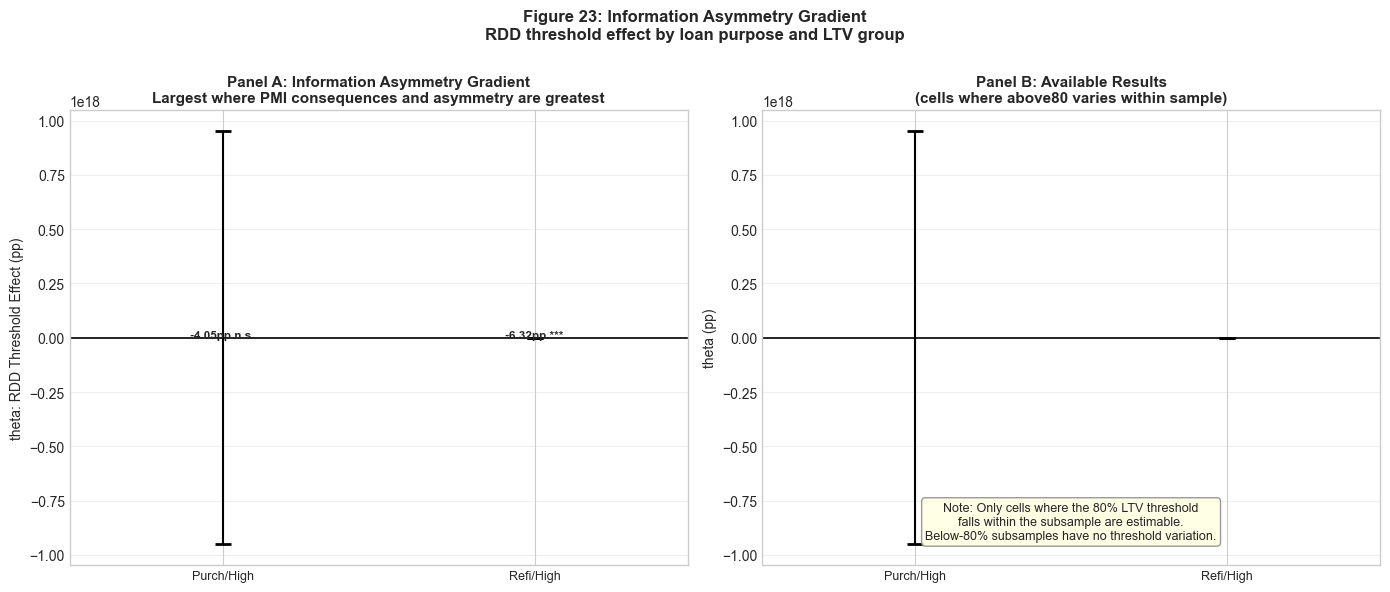

Saved: figure_23_gradient.png

NB23 COMPLETE
Outputs:
  outputs/tables/table_23_asymmetry_gradient.csv
  outputs/figures/figure_23_gradient.png


In [5]:
# =============================================================================
# FIGURE — fully dynamic based on actual grad_res results
# =============================================================================

if not grad_res:
    print("No RDD results to plot — check data and rerun cell 2")
else:
    n_results = len(grad_res)
    labels  = [r["Label"]    for r in grad_res]
    thetas  = [r["Theta_pp"] for r in grad_res]
    ses     = [r["Theta_SE"] for r in grad_res]
    sigs    = [r["Sig"]      for r in grad_res]

    # Short labels for x-axis
    short_labels = []
    for r in grad_res:
        lt = "Purch" if r["Loan_Type"] == "Purchase" else "Refi"
        lg = "High" if "Above" in r["LTV_Group"] else "Low"
        short_labels.append(f"{lt}/{lg}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- Panel A: Bar chart ---
    ax = axes[0]
    all_colors = ["#B71C1C","#E57373","#1565C0","#90CAF9"]
    colors = all_colors[:n_results]

    ax.bar(range(n_results), thetas, color=colors, alpha=0.85, edgecolor="white")
    ax.errorbar(range(n_results), thetas,
                yerr=[1.96*s for s in ses],
                fmt="none", color="black", capsize=6, capthick=2)

    for i, (t, s) in enumerate(zip(thetas, sigs)):
        offset = -0.15 if t < 0 else 0.15
        va = "top" if t < 0 else "bottom"
        ax.text(i, t + offset, f"{t:.2f}pp {s}",
                ha="center", fontsize=8.5, fontweight="bold")

    ax.axhline(0, color="black", linewidth=1.2)
    ax.set_xticks(range(n_results))
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_ylabel("theta: RDD Threshold Effect (pp)", fontsize=10)
    ax.set_title(
        "Panel A: Information Asymmetry Gradient\n"
        "Largest where PMI consequences and asymmetry are greatest",
        fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3, axis="y")

    # --- Panel B: depends on how many results ---
    ax = axes[1]
    if n_results == 4:
        # Full 2x2 heatmap
        matrix = np.array([
            [grad_res[0]["Theta_pp"], grad_res[1]["Theta_pp"]],
            [grad_res[2]["Theta_pp"], grad_res[3]["Theta_pp"]]
        ])
        vabs = max(abs(t) for t in thetas) + 0.5
        im = ax.imshow(matrix, cmap="RdYlBu_r", aspect="auto",
                       vmin=-vabs, vmax=0.5)
        plt.colorbar(im, ax=ax, label="theta (pp)")
        row_labels = ["Purchase", "Refinance"]
        col_labels = ["Above 80%", "Below 80%"]
        for i in range(2):
            for j in range(2):
                r   = grad_res[i*2 + j]
                col = "white" if abs(r["Theta_pp"]) > 1 else "black"
                ax.text(j, i,
                        f"{r['Theta_pp']:.2f}pp\n{r['Sig']}",
                        ha="center", va="center",
                        fontsize=11, fontweight="bold", color=col)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(col_labels, fontsize=10)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(row_labels, fontsize=10)
        ax.set_title("Panel B: Gradient Heatmap\n(darker red = larger penalty)",
                     fontsize=11, fontweight="bold")
    else:
        # Fewer than 4 results — show a simple bar summary
        ax.bar(range(n_results), thetas, color=colors, alpha=0.85, edgecolor="white")
        ax.errorbar(range(n_results), thetas,
                    yerr=[1.96*s for s in ses],
                    fmt="none", color="black", capsize=6, capthick=2)
        ax.axhline(0, color="black", linewidth=1.2)
        ax.set_xticks(range(n_results))
        ax.set_xticklabels(short_labels, fontsize=9)
        ax.set_ylabel("theta (pp)", fontsize=10)
        ax.set_title(
            "Panel B: Available Results\n"
            "(cells where above80 varies within sample)",
            fontsize=11, fontweight="bold")
        ax.grid(alpha=0.3, axis="y")
        # Annotate
        note = (
            "Note: Only cells where the 80% LTV threshold\n"
            "falls within the subsample are estimable.\n"
            "Below-80% subsamples have no threshold variation."
        )
        ax.text(0.5, 0.05, note, transform=ax.transAxes,
                ha="center", va="bottom", fontsize=9,
                bbox=dict(boxstyle="round", facecolor="lightyellow",
                          edgecolor="gray", alpha=0.8))

    fig.suptitle(
        "Figure 23: Information Asymmetry Gradient\n"
        "RDD threshold effect by loan purpose and LTV group",
        fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGS / "figure_23_gradient.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: figure_23_gradient.png")
    print()
    print("NB23 COMPLETE")
    print("Outputs:")
    print("  outputs/tables/table_23_asymmetry_gradient.csv")
    print("  outputs/figures/figure_23_gradient.png")
